# ABCDEats Dataset Exploratory Data Analysis (EDA)

## Overview
This notebook performs a comprehensive exploratory data analysis of the ABCDEats dataset. It examines the structure, data types, missing values, and statistical distributions of key features to guide data preprocessing and feature engineering efforts.

## Objectives
- Load and inspect the dataset structure
- Identify data types and missing values
- Analyze key features (customer demographics, ordering behavior, temporal patterns)
- Detect outliers and anomalies
- Understand feature distributions across different dimensions

---

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns 

# Configure visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [2]:
# Load the dataset
file_path = '../Data/ABCDEats_DATASET.csv'
df = pd.read_csv(file_path)

# Display basic information about dataset shape
shape_of_df = df.shape
print(f"Dataset shape: {shape_of_df[0]} rows × {shape_of_df[1]} columns")
shape_of_df

(31888, 56)

## 1. Data Loading and Inspection

In [3]:
# Display data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31888 entries, 0 to 31887
Data columns (total 56 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               31888 non-null  object 
 1   customer_region           31888 non-null  object 
 2   customer_age              31161 non-null  float64
 3   vendor_count              31888 non-null  int64  
 4   product_count             31888 non-null  int64  
 5   is_chain                  31888 non-null  int64  
 6   first_order               31782 non-null  float64
 7   last_order                31888 non-null  int64  
 8   last_promo                31888 non-null  object 
 9   payment_method            31888 non-null  object 
 10  CUI_American              31888 non-null  float64
 11  CUI_Asian                 31888 non-null  float64
 12  CUI_Beverages             31888 non-null  float64
 13  CUI_Cafe                  31888 non-null  float64
 14  CUI_Ch

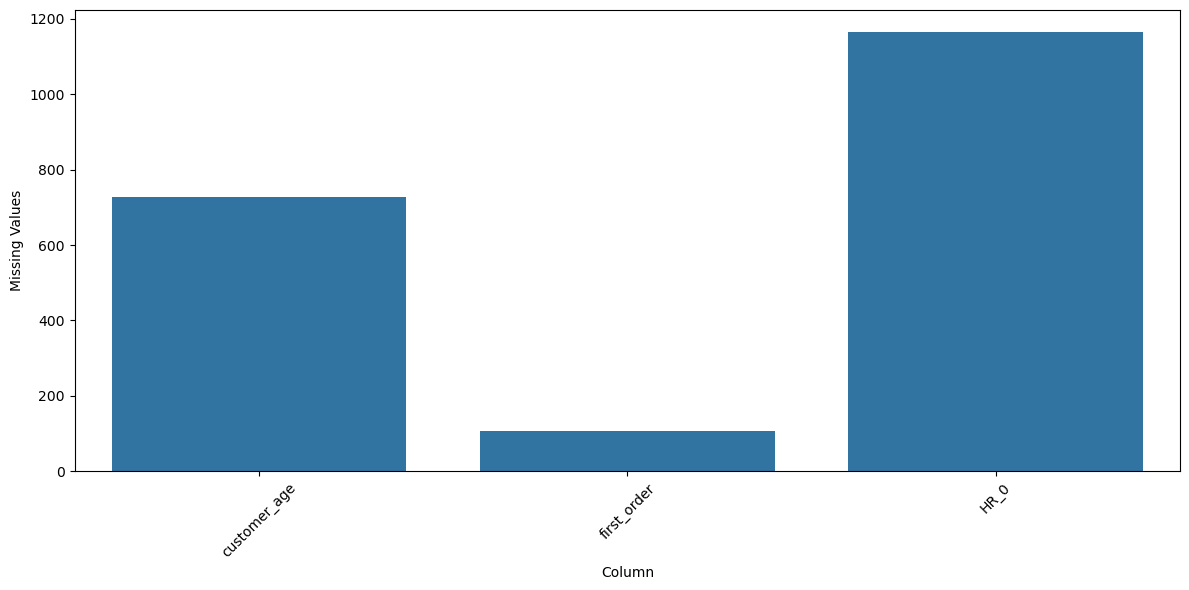

In [4]:
# Analyze missing values per column
column_names = list(df.columns)
missing_values_count = df.isna().sum()
missing_values_df = pd.DataFrame({
    'Column': column_names, 
    'Missing Values': missing_values_count,
    'Missing %': (missing_values_count / len(df) * 100).round(2)
})
missing_values_df_filtered = missing_values_df[missing_values_df['Missing Values'] > 0]

print(f"Columns with missing values:\n{missing_values_df_filtered}\n")

# Visualize missing values
if len(missing_values_df_filtered) > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Column', y='Missing Values', data=missing_values_df_filtered)
    plt.title('Missing Values Count by Column')
    plt.xlabel('Column Name')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset")

In [5]:
# Classify numerical columns by feature type
numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Total numerical columns: {len(numerical_columns)}\n")

# Extract feature groups
HOR_columns = [col for col in numerical_columns if 'HR_' in col]
print(f"Hour-based features (HR_): {len(HOR_columns)} columns")

DOW_columns = [col for col in numerical_columns if 'DOW_' in col]
print(f"Day-of-week features (DOW_): {len(DOW_columns)} columns")

CUISINE_columns = [col for col in numerical_columns if 'CUI_' in col]
print(f"Cuisine-based features (CUI_): {len(CUISINE_columns)} columns")

# Other numerical features
others_numerical_columns = [col for col in numerical_columns 
                            if col not in HOR_columns and col not in DOW_columns and col not in CUISINE_columns]
print(f"Other numerical features: {len(others_numerical_columns)} columns")
print(f"Examples: {others_numerical_columns}")

Numerical Columns: ['customer_age', 'vendor_count', 'product_count', 'is_chain', 'first_order', 'last_order', 'CUI_American', 'CUI_Asian', 'CUI_Beverages', 'CUI_Cafe', 'CUI_Chicken Dishes', 'CUI_Chinese', 'CUI_Desserts', 'CUI_Healthy', 'CUI_Indian', 'CUI_Italian', 'CUI_Japanese', 'CUI_Noodle Dishes', 'CUI_OTHER', 'CUI_Street Food / Snacks', 'CUI_Thai', 'DOW_0', 'DOW_1', 'DOW_2', 'DOW_3', 'DOW_4', 'DOW_5', 'DOW_6', 'HR_0', 'HR_1', 'HR_2', 'HR_3', 'HR_4', 'HR_5', 'HR_6', 'HR_7', 'HR_8', 'HR_9', 'HR_10', 'HR_11', 'HR_12', 'HR_13', 'HR_14', 'HR_15', 'HR_16', 'HR_17', 'HR_18', 'HR_19', 'HR_20', 'HR_21', 'HR_22', 'HR_23']
HOR Columns: ['HR_0', 'HR_1', 'HR_2', 'HR_3', 'HR_4', 'HR_5', 'HR_6', 'HR_7', 'HR_8', 'HR_9', 'HR_10', 'HR_11', 'HR_12', 'HR_13', 'HR_14', 'HR_15', 'HR_16', 'HR_17', 'HR_18', 'HR_19', 'HR_20', 'HR_21', 'HR_22', 'HR_23']
DOW Columns: ['DOW_0', 'DOW_1', 'DOW_2', 'DOW_3', 'DOW_4', 'DOW_5', 'DOW_6']
Cuisine Columns: ['CUI_American', 'CUI_Asian', 'CUI_Beverages', 'CUI_Cafe', 'CU

In [6]:
# Identify and list categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns ({len(categorical_columns)} total):")
for col in categorical_columns:
    print(f"  - {col}")

Categorical Columns: ['customer_id', 'customer_region', 'last_promo', 'payment_method']


## 2. Categorical Features Analysis

### 2.1 Customer ID Analysis
Examining the customer_id column to identify duplicates and data quality issues.

In [7]:
# Display sample customer IDs
print("Sample customer IDs:")
print(df['customer_id'].head(10))

0    1b8f824d5e
1    5d272b9dcb
2    f6d1b2ba63
3    180c632ed8
4    4eb37a6705
Name: customer_id, dtype: object

**Observation:** Customer IDs are alphanumeric strings. Next, we'll check for duplicate customer entries.

In [8]:
# Check for duplicate customer IDs
duplicate_counts = df['customer_id'].value_counts()
duplicates_with_multiple_entries = duplicate_counts[duplicate_counts > 1]

print(f"Number of customer IDs with duplicates: {len(duplicates_with_multiple_entries)}")
print("\nTop customer IDs by occurrence count:")
print(duplicates_with_multiple_entries.head(14))

customer_id
742ca068fc    2
cc08ef25ce    2
b55012ee1c    2
cf563a0a98    2
fac7984c0d    2
06018a56be    2
8aa9bbc147    2
671bf0c738    2
b8e7a643a4    2
201a13a34d    2
24251eb7da    2
6bbf5f74cd    2
df91183978    2
6aef2b6726    1
Name: count, dtype: int64

**Finding:** There are 13 customer IDs with multiple entries. We'll analyze if these duplicates represent identical records or if they contain different information.

In [9]:
# Get list of duplicate customer IDs
duplicate_customer_ids = df['customer_id'][df['customer_id'].duplicated(keep=False)].unique().tolist()
print(f"Number of unique customer IDs with duplicates: {len(duplicate_customer_ids)}")
print(f"Duplicate customer IDs: {duplicate_customer_ids}")
# here I'm using df instead of df to check for duplicates across the entire dataset, including both training and testing sets.
# handling duplicates in like this does not constitute as data leakage, quite the opposite.

['b55012ee1c',
 'b55012ee1c',
 '24251eb7da',
 '24251eb7da',
 '671bf0c738',
 '671bf0c738',
 '742ca068fc',
 '742ca068fc',
 'df91183978',
 'df91183978',
 '6bbf5f74cd',
 '6bbf5f74cd',
 '8aa9bbc147',
 '8aa9bbc147',
 'cf563a0a98',
 'cf563a0a98',
 '201a13a34d',
 '201a13a34d',
 '06018a56be',
 '06018a56be',
 'fac7984c0d',
 'fac7984c0d',
 'b8e7a643a4',
 'b8e7a643a4',
 'cc08ef25ce',
 'cc08ef25ce']

In [10]:
# Check if duplicate customer records have different values in any column
# This approach iterates through each duplicate customer and examines all columns
# to identify if their records have inconsistent data values

unequal_customer_ids = []
for customer_id in set(duplicate_customer_ids):
    # Get all records for this customer ID
    df_of_customer = df[df['customer_id'] == customer_id]
    
    for label in df.columns:
        # Count unique values in this column for the duplicate records
        # Note: value_counts() ignores NaN values by default
        # - If count < 1: Only NaN values exist in this column for these records
        # - If count = 1: All records have the same value (no variation)
        # - If count > 1: Different values exist for this column (data inconsistency)
        unique_value_count = len(df_of_customer[label].value_counts())
        
        if unique_value_count > 1:
            # Record this (customer_id, column) pair as having inconsistent data
            unequal_customer_ids.append((customer_id, label))
            
if unequal_customer_ids:
    print(f"Found {len(unequal_customer_ids)} column variations in duplicate records:")
    print(unequal_customer_ids)
else:
    print("No variations found - all duplicate customer records have identical values")

[]

**Alternative Method: Using Pandas GroupBy**

The second approach uses pandas' `groupby().nunique()` method to count unique values per column for duplicate customer IDs. This is more efficient than nested loops and better suited for large datasets. We'll reshape and filter the results to identify columns with inconsistent data.

**Comparison:**
- First method (nested loops): More explicit, easier to understand for beginners, slower for large datasets
- Second method (groupby): More Pythonic, optimized for pandas, scales better with data size

In [ ]:
# Alternative, more efficient approach to check duplicates using pandas groupby
# This method is more scalable than the nested loop approach

# Filter the DataFrame to only include records with duplicate customer IDs
df_dupes = df[df['customer_id'].isin(duplicate_customer_ids)]

# Group by customer_id and count unique values per column
# dropna=True ensures NA values are not counted (mimics value_counts() behavior)
unique_counts = df_dupes.groupby('customer_id').nunique(dropna=True)

# Reshape the result: pivot from wide format (customers as rows, columns as columns)
# to long format (customer_id, column_name, unique_count per row)
# Then filter for values > 1 to identify columns with inconsistent data
stacked = unique_counts.stack()
unequal_customer_ids = stacked[stacked > 1].index.tolist()

# Print results: display all (customer_id, column_name) pairs with variations
if unequal_customer_ids:
    print(f"Found {len(unequal_customer_ids)} column variations in duplicate records:")
    print(unequal_customer_ids)
else:
    print("No variations found - all duplicate customer records have identical values")

In [ ]:
# drop duplicates
df = df.drop_duplicates(subset='customer_id', keep='first').reset_index(drop=True)
print(f"Dataset shape after dropping duplicates: {df.shape}")

**Conclusion:** All duplicate customer records are completely identical (same values across all columns). These can be safely removed as duplicates without loss of information.

## data split
we cna now procede with the data split, since we have identified that there are no duplicates with different values, we can safely remove the duplicates without risking data leakage.

In [ ]:
# import scikit-learn  and split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
print(f"Training set shape: {df_train.shape}")
print(f"Testing set shape: {df_test.shape}")

### 2.2 Customer Age Analysis
Analyzing the distribution and outliers in the customer age feature using descriptive statistics and visualization.

In [12]:
# Display descriptive statistics for customer age
print("Customer Age Statistics:")
print(df['customer_age'].describe())

count    31161.000000
mean        27.506499
std          7.160898
min         15.000000
25%         23.000000
50%         26.000000
75%         31.000000
max         80.000000
Name: customer_age, dtype: float64

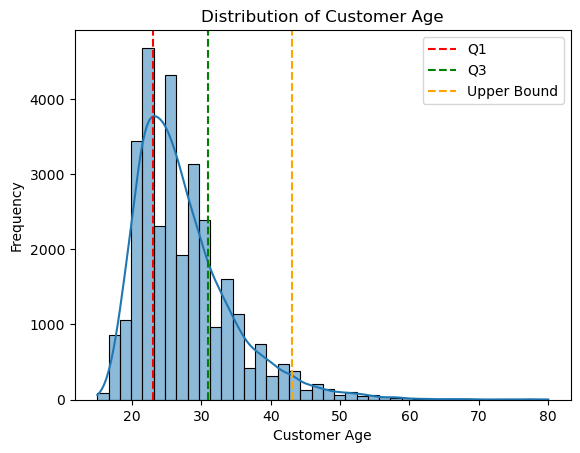

In [15]:
# Visualize customer age distribution with outlier bounds (IQR method)
Q1 = df['customer_age'].quantile(0.25)
Q3 = df['customer_age'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(df['customer_age'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1 ({Q1:.0f})')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3 ({Q3:.0f})')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Outlier Bound ({upper_bound:.0f})')
plt.axvline(lower_bound, color='purple', linestyle='--', linewidth=2, label=f'Lower Outlier Bound ({lower_bound:.0f})')
plt.legend()
plt.title('Distribution of Customer Age with Outlier Bounds (IQR Method)')
plt.xlabel('Customer Age (years)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 3. Numerical Features Analysis

### 3.1 Vendor Count Analysis
Analyzing the number of vendors each customer has interacted with.

In [16]:
# Display descriptive statistics for vendor count
print("Vendor Count Statistics:")
print(df['vendor_count'].describe())

count    31888.000000
mean         3.102609
std          2.771587
min          0.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         41.000000
Name: vendor_count, dtype: float64

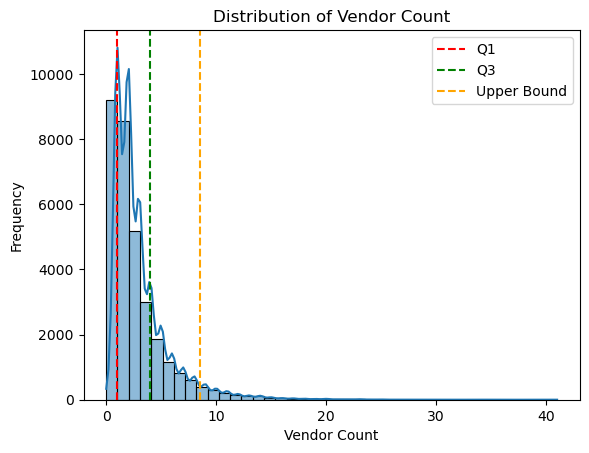

In [17]:
# Visualize vendor count distribution with outlier detection (IQR method)
Q1 = df['vendor_count'].quantile(0.25)
Q3 = df['vendor_count'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(df['vendor_count'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1 ({Q1:.0f})')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3 ({Q3:.0f})')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Outlier Bound ({upper_bound:.0f})')
plt.legend()
plt.title('Distribution of Vendor Count with Outlier Bounds (IQR Method)')
plt.xlabel('Number of Vendors')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### 3.2 Product Count Analysis
Analyzing the number of unique products each customer has purchased.

In [19]:
# Display descriptive statistics for product count
print("Product Count Statistics:")
print(df['product_count'].describe())

count    31888.000000
mean         5.668245
std          6.957287
min          0.000000
25%          2.000000
50%          3.000000
75%          7.000000
max        269.000000
Name: product_count, dtype: float64

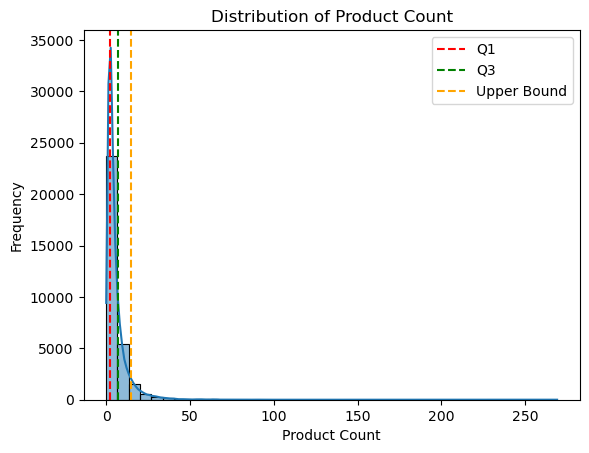

In [18]:
# Visualize product count distribution with outlier detection (IQR method)
Q1 = df['product_count'].quantile(0.25)
Q3 = df['product_count'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(df['product_count'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1 ({Q1:.0f})')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3 ({Q3:.0f})')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Outlier Bound ({upper_bound:.0f})')
plt.legend()
plt.title('Distribution of Product Count with Outlier Bounds (IQR Method)')
plt.xlabel('Number of Products')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### 3.3 Is Chain Analysis
Analyzing the binary feature indicating whether customers order from chain restaurants.

In [20]:
# Display statistics for is_chain feature
print("Is Chain Feature Statistics:")
print(df['is_chain'].describe())
print(f"\nValue counts:\n{df['is_chain'].value_counts()}")

count    31888.000000
mean         2.818866
std          3.977529
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         83.000000
Name: is_chain, dtype: float64

In [22]:
# Analyze is_chain for customers with zero product count
df_zero_products = df[df['product_count'] == 0]
print(f"Customers with zero product count: {len(df_zero_products)}")
print("Is Chain statistics for zero-product customers:")
print(df_zero_products['is_chain'].describe())

count    156.000000
mean       0.480769
std        0.501239
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: is_chain, dtype: float64

### 3.4 Temporal Features Analysis
Analyzing ordering patterns over time (first order, last order, and customer permanence).

In [23]:
# Display descriptive statistics for first order date
print("First Order Date Statistics:")
print(df['first_order'].describe())

count    31782.000000
mean        28.478604
std         24.109086
min          0.000000
25%          7.000000
50%         22.000000
75%         45.000000
max         90.000000
Name: first_order, dtype: float64

In [24]:
# Display descriptive statistics for last order date
print("Last Order Date Statistics:")
print(df['last_order'].describe())

count    31888.000000
mean        63.675521
std         23.226123
min          0.000000
25%         49.000000
50%         70.000000
75%         83.000000
max         90.000000
Name: last_order, dtype: float64

In [25]:
# Calculate customer permanence (duration from first to last order)
permanence = df['last_order'] - df['first_order']
print("Customer Permanence Statistics (days from first to last order):")
print(permanence.describe())

count    31782.000000
mean        35.409288
std         29.417128
min          0.000000
25%          3.000000
50%         34.000000
75%         62.000000
max         90.000000
dtype: float64

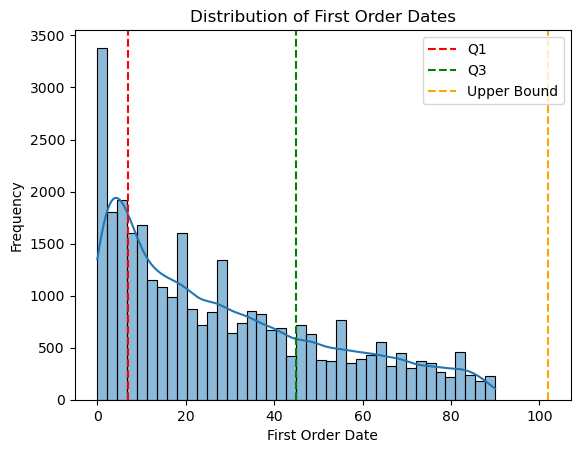

In [27]:
# Visualize first order date distribution with outlier bounds
Q1 = df['first_order'].quantile(0.25)
Q3 = df['first_order'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(df['first_order'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label='Upper Outlier Bound')
plt.legend()
plt.title('Distribution of First Order Dates with Outlier Bounds')
plt.xlabel('First Order Date (days since epoch)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

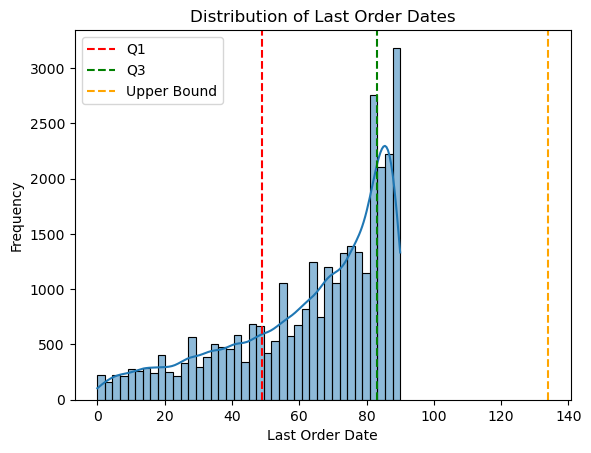

In [28]:
# Visualize last order date distribution with outlier bounds
Q1 = df['last_order'].quantile(0.25)
Q3 = df['last_order'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(df['last_order'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Outlier Bound')
plt.legend()
plt.title('Distribution of Last Order Dates with Outlier Bounds')
plt.xlabel('Last Order Date (days since epoch)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

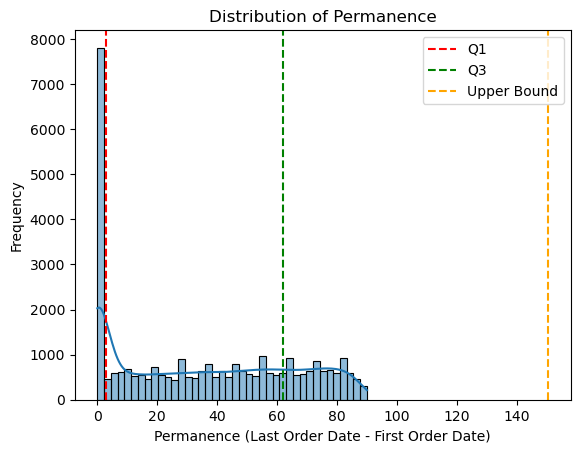

In [30]:
# Visualize customer permanence distribution with outlier bounds
Q1 = permanence.quantile(0.25)
Q3 = permanence.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(permanence, bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label='Upper Outlier Bound')
plt.legend()
plt.title('Distribution of Customer Permanence with Outlier Bounds')
plt.xlabel('Permanence (Last Order Date - First Order Date in days)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [36]:
# Identify customers with zero values for both first and last order dates
zero_order_dates = df[(df['first_order'] == 0) & (df['last_order'] == 0)]
print(f"Customers with both first_order and last_order = 0: {len(zero_order_dates)}")
if len(zero_order_dates) > 0:
    print(f"First few records:\n{zero_order_dates.head()}")

,customer_id,customer_region,customer_age,vendor_count,product_count,is_chain,first_order,last_order,last_promo,payment_method,...,HR_14,HR_15,HR_16,HR_17,HR_18,HR_19,HR_20,HR_21,HR_22,HR_23


In [40]:
# Analyze product_count for customers with last_order = 0
zero_last_order = df[df['last_order'] == 0]
print(f"Customers with last_order = 0: {len(zero_last_order)}")
print("\nProduct count statistics for these customers:")
print(zero_last_order['product_count'].describe())

count    106.000000
mean       1.311321
std        0.721945
min        1.000000
25%        1.000000
50%        1.000000
75%        1.750000
max        7.000000
Name: product_count, dtype: float64

## 4. Categorical Features Analysis

This section explores the categorical variables in the dataset.

### 4.1 Customer Region Analysis
Examining customer distribution and ordering patterns across different regions.

In [ ]:
# Display distribution of customers by region
print("Customer Distribution by Region:")
region_counts = df['customer_region'].value_counts()
print(region_counts)
print("\nPercentage distribution:")
print((region_counts / len(df) * 100).round(2))

customer_region
8670    9761
4660    9550
2360    8829
2440    1483
4140     857
8370     495
2490     445
-        442
8550      26
Name: count, dtype: int64

In [50]:
# Analyze first_order statistics by region
print("First Order Date Statistics by Customer Region:")
region_stats = df.groupby('customer_region')['first_order'].describe()
print(region_stats)

,count,mean,std,min,25%,50%,75%,max
customer_region,,,,,,,,
-,439.0,31.141230,25.407512,0.0,8.00,26.0,50.00,89.0
2360,8806.0,25.021236,22.844275,0.0,6.00,18.0,38.00,89.0
2440,1478.0,24.512855,22.061759,0.0,6.00,19.0,36.00,90.0
2490,445.0,26.350562,22.637732,0.0,7.00,20.0,41.00,88.0
4140,856.0,35.261682,25.739300,0.0,13.00,31.0,56.25,89.0
4660,9524.0,28.696556,24.411737,0.0,7.00,22.0,45.00,89.0
8370,494.0,35.925101,25.029404,0.0,14.25,32.0,56.00,89.0
8550,26.0,49.692308,26.130089,2.0,35.00,53.0,67.00,88.0
8670,9714.0,30.946469,24.456043,0.0,9.00,26.0,49.00,89.0


### 4.2 Last Promo Analysis
Analyzing promotional offer engagement across the customer base.

In [52]:
# Display distribution of last promotional offer interaction
print("Distribution of Last Promo Interaction:")
promo_counts = df['last_promo'].value_counts()
print(promo_counts)
print(f"\nPercentage distribution:")
print((promo_counts / len(df) * 100).round(2))

last_promo
-           16748
DELIVERY     6286
DISCOUNT     4496
FREEBIE      4358
Name: count, dtype: int64

### 4.3 Payment Method Analysis
Examining customer preferences for payment methods.

In [ ]:
# Display distribution of payment methods
print("Distribution of Payment Methods:")
payment_counts = df['payment_method'].value_counts()
print(payment_counts)
print("\nPercentage distribution:")
print((payment_counts / len(df) * 100).round(2))

payment_method
CARD    20161
DIGI     6101
CASH     5626
Name: count, dtype: int64

## 5. Day-of-Week (DOW) Features Analysis
Analyzing customer ordering patterns by day of week (Monday through Sunday).

In [54]:
# Display descriptive statistics for all DOW columns
print("Descriptive Statistics for Day-of-Week Features:")
print(df[DOW_columns].describe().round(2))

,DOW_0,DOW_1,DOW_2,DOW_3,DOW_4,DOW_5,DOW_6
count,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000
mean,0.555914,0.567486,0.591006,0.619449,0.677747,0.652973,0.704246
std,1.013601,1.044090,1.045907,1.069672,1.088122,1.069947,1.167446
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,16.000000,17.000000,15.000000,17.000000,16.000000,20.000000,20.000000


In [56]:
# Check for missing values in DOW columns
dow_missing = df[DOW_columns].isna().sum()
print("Missing Values in DOW Columns:")
print(dow_missing)
if dow_missing.sum() == 0:
    print("✓ No missing values found in DOW features")

DOW_0    0
DOW_1    0
DOW_2    0
DOW_3    0
DOW_4    0
DOW_5    0
DOW_6    0
dtype: int64

## 6. Hour-of-Day (HR) Features Analysis
Analyzing customer ordering patterns by hour of the day (0-23 hours).

In [57]:
# Display descriptive statistics for all HR columns
print(f"Descriptive Statistics for Hour-of-Day Features ({len(HOR_columns)} features):")
print(df[HOR_columns].describe().round(2))

,HR_0,HR_1,HR_2,HR_3,HR_4,HR_5,HR_6,HR_7,HR_8,HR_9,...,HR_14,HR_15,HR_16,HR_17,HR_18,HR_19,HR_20,HR_21,HR_22,HR_23
count,30723.0,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.0000,31888.000000,31888.000000,...,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000
mean,0.0,0.053845,0.063190,0.118759,0.101700,0.081943,0.069681,0.0768,0.131899,0.233912,...,0.215630,0.277032,0.356435,0.390962,0.336961,0.245610,0.142812,0.071155,0.048263,0.045189
std,0.0,0.317013,0.351498,0.500862,0.437493,0.358705,0.329461,0.3777,0.635582,0.724906,...,0.599006,0.738162,0.874449,0.943721,0.893949,0.795296,0.586529,0.348536,0.298265,0.282006
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,0.0,14.000000,12.000000,11.000000,14.000000,7.000000,8.000000,15.0000,52.000000,23.000000,...,13.000000,23.000000,22.000000,20.000000,24.000000,35.000000,36.000000,11.000000,15.000000,13.000000


In [58]:
# Check for missing values in HR columns
hor_missing = df[HOR_columns].isna().sum()
print("Missing Values in HR Columns:")
print(hor_missing)
if hor_missing.sum() == 0:
    print("✓ No missing values found in HR features")

HR_0     1165
HR_1        0
HR_2        0
HR_3        0
HR_4        0
HR_5        0
HR_6        0
HR_7        0
HR_8        0
HR_9        0
HR_10       0
HR_11       0
HR_12       0
HR_13       0
HR_14       0
HR_15       0
HR_16       0
HR_17       0
HR_18       0
HR_19       0
HR_20       0
HR_21       0
HR_22       0
HR_23       0
dtype: int64

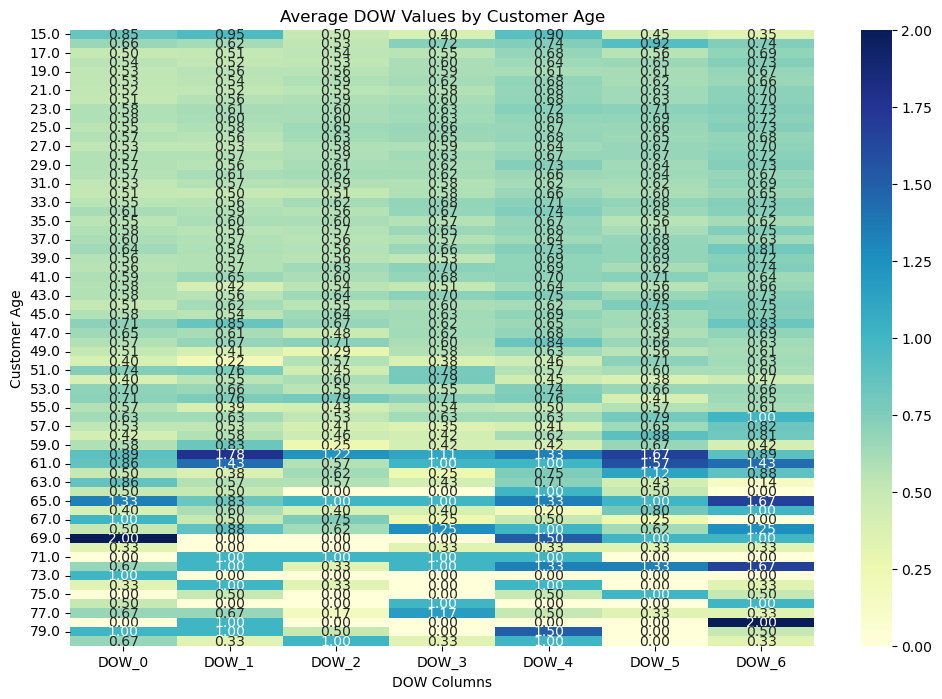

In [64]:
# Visualize average DOW values by customer age
df_for_heatmap = df.groupby('customer_age')[DOW_columns].mean()

plt.figure(figsize=(14, 8))
sns.heatmap(df_for_heatmap, cmap='YlGnBu', annot=True, fmt=".2f", cbar_kws={'label': 'Average Orders'})
plt.title('Average Day-of-Week Ordering Patterns by Customer Age', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Customer Age', fontsize=12)
plt.tight_layout()
plt.show()

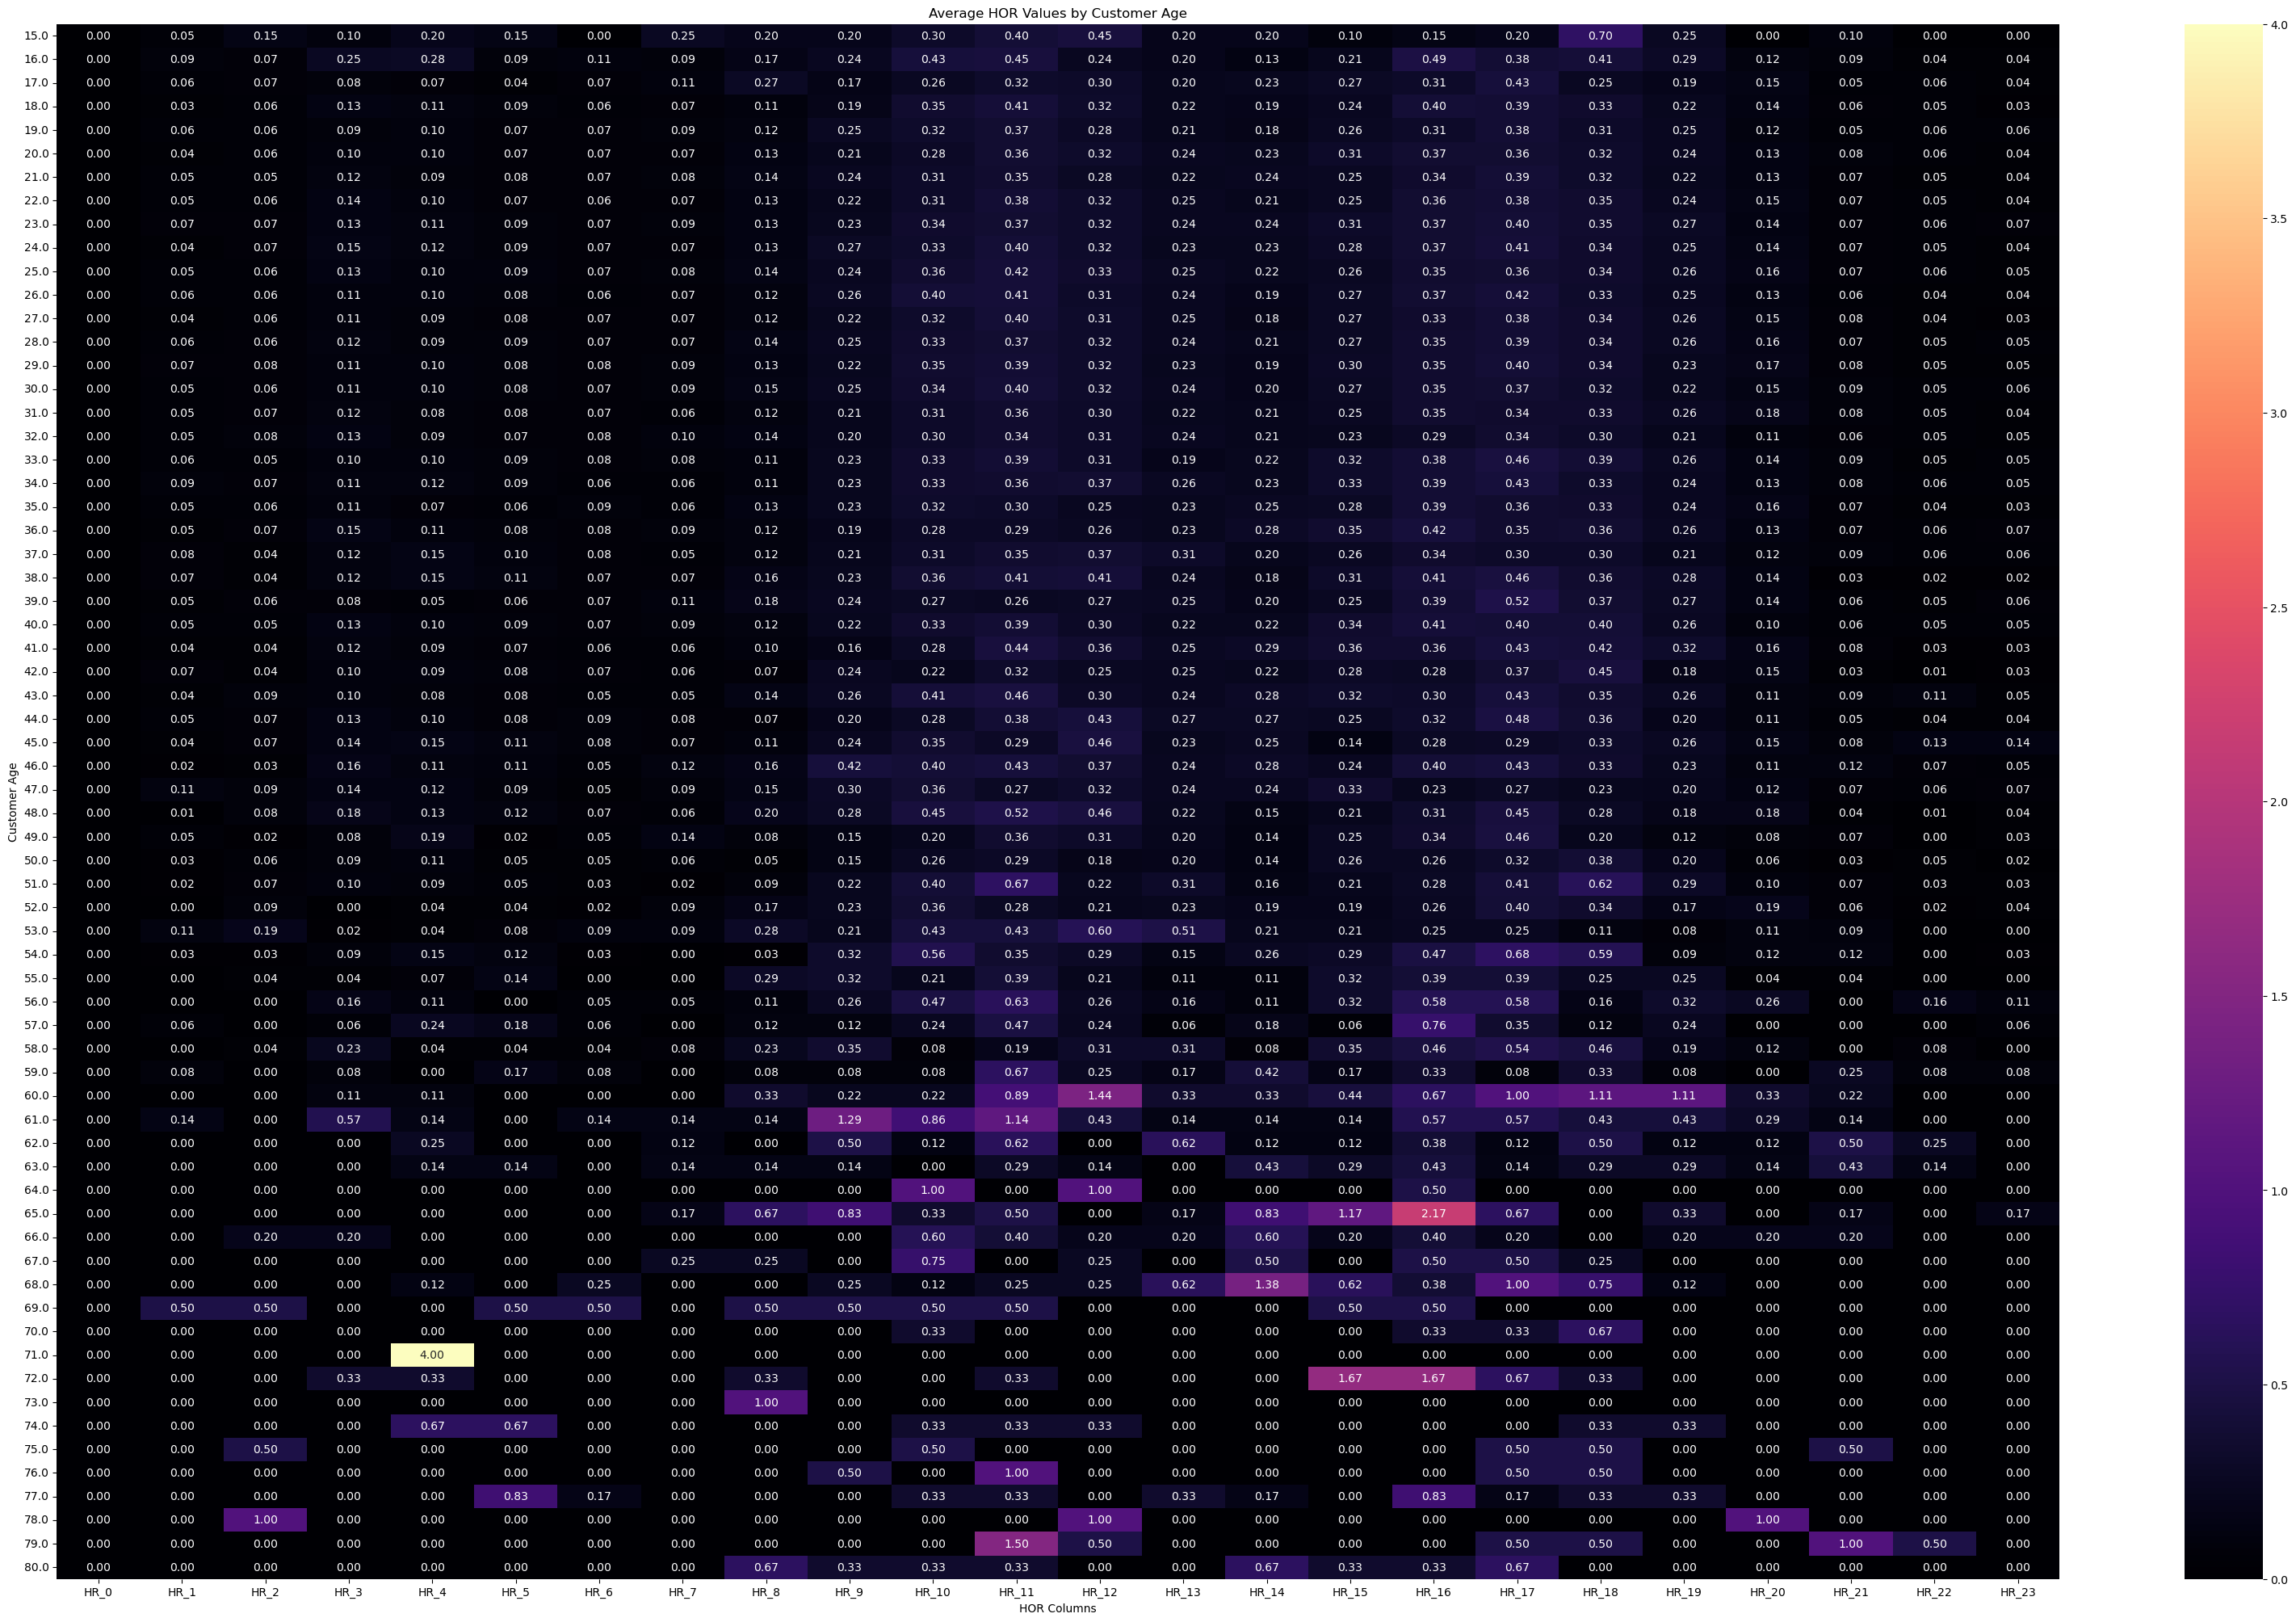

In [68]:
# Visualize average HR values by customer age
df_for_heatmap = df.groupby('customer_age')[HOR_columns].mean()

plt.figure(figsize=(20, 10))
sns.heatmap(df_for_heatmap, cmap='magma', annot=True, fmt=".2f", cbar_kws={'label': 'Average Orders'})
plt.title('Average Hour-of-Day Ordering Patterns by Customer Age', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Customer Age', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Cuisine Features Analysis
Analyzing customer preferences across different cuisine types.

In [69]:
# Display descriptive statistics for all cuisine columns
print(f"Descriptive Statistics for Cuisine Features ({len(CUISINE_columns)} features):")
print(df[CUISINE_columns].describe().round(2))

,CUI_American,CUI_Asian,CUI_Beverages,CUI_Cafe,CUI_Chicken Dishes,CUI_Chinese,CUI_Desserts,CUI_Healthy,CUI_Indian,CUI_Italian,CUI_Japanese,CUI_Noodle Dishes,CUI_OTHER,CUI_Street Food / Snacks,CUI_Thai
count,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000
mean,4.880438,9.960451,2.300633,0.801163,0.768096,1.431218,0.884359,0.950203,1.631153,3.233411,2.995379,0.711676,2.999913,3.913253,0.841697
std,11.654018,23.564351,8.479734,6.427132,3.657273,8.191755,5.259868,5.830590,7.443234,11.247990,10.180851,4.536457,9.768300,15.548507,4.433047
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.660000,11.830000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,280.210000,896.710000,229.220000,326.100000,219.660000,739.730000,230.070000,255.810000,309.070000,468.330000,706.140000,275.110000,366.080000,454.450000,136.380000


In [70]:
# Display sample cuisine data
print("Sample Cuisine Feature Data:")
print(df[CUISINE_columns].head(10))

,CUI_American,CUI_Asian,CUI_Beverages,CUI_Cafe,CUI_Chicken Dishes,CUI_Chinese,CUI_Desserts,CUI_Healthy,CUI_Indian,CUI_Italian,CUI_Japanese,CUI_Noodle Dishes,CUI_OTHER,CUI_Street Food / Snacks,CUI_Thai
0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,28.88,0.0,0.0,0.0,0.0,0.0,0.0
1,12.82,6.39,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0
2,9.20,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0
3,0.00,13.70,0.0,0.0,0.0,0.0,0.0,0.0,17.86,0.0,0.0,0.0,0.0,0.0,0.0
4,14.57,40.87,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0
